In [1]:
!pip -q install torch torchdiffeq pykan numpy scipy matplotlib

In [2]:
import numpy as np
import torch
from functools import reduce
from torch.optim import Optimizer
import kan.LBFGS as LBFGS
import math


# -----------------------------
# Constants + helpers for Kuramoto-Oscillators
# -----------------------------
TWOPI = 2 * np.pi

def wrap_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def wrap_pi_torch(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def unwrap_for_plot(traj_wrapped):
    return np.unwrap(traj_wrapped, axis=0)


def fit(
    model, dataset, opt="LBFGS", steps=100, log=1,
    lamb=0., lamb_l1=1., lamb_entropy=2., lamb_coef=0., lamb_coefdiff=0.,
    update_grid=True, grid_update_num=10, loss_fn=None, lr=1.,
    start_grid_update_step=-1, stop_grid_update_step=50, batch=-1, metrics=None,
    in_vars=None, out_vars=None, beta=3, singularity_avoiding=False, y_th=1000.,
    reg_metric='edge_forward_spline_n', display_metrics=None, k=1,

    # ---- NEW: integrated rollout loss ------------------------------------------
    rollout_weight=0.0,          # set >0 to enable integration loss
    rollout_horizon=None,        # int number of steps (<= T-1). None => use full T-1
    traj_batch=-1,               # how many trajectories per step (-1 => all)
    dynamics_fn=None,            # optional: f(state)->dstate/dt. defaults to model.forward(state)
    integrator="rk4",            # "euler" or "rk4"
):
    """
    Adds an optional differentiable integration loss:
        if dataset contains 'train_traj' and 'train_t' and rollout_weight>0,
        we integrate ds/dt = f_theta(s) and match predicted states to train_traj.

    Notes:
    - This assumes the model maps STATE -> DERIVATIVE for the rollout term.
      If your model needs feature transforms (Theta, normalization, etc.),
      pass a custom dynamics_fn(state) that does that and returns dstate/dt.
    """

    assert k >= 1, "k must be >= 1"

    # -------------------------------------------------------------------------
    # Original k-step forward (kept for backward compatibility)
    # -------------------------------------------------------------------------
    def k_step_forward(inputs):
        state = inputs
        for _ in range(k):
            state = model.forward(state, singularity_avoiding=singularity_avoiding, y_th=y_th)
        return state

    # -------------------------------------------------------------------------
    # NEW: dynamics function for ODE rollout
    # -------------------------------------------------------------------------
    if dynamics_fn is None:
        def dynamics_fn(state):
            # default: treat model.forward(state) as f_theta(state)
            return model.forward(state, singularity_avoiding=singularity_avoiding, y_th=y_th)

    # Differentiable integrators (batch-safe)
    def euler_step(s, dt):
        return s + dt * dynamics_fn(s)

    def rk4_step(s, dt):
        k1 = dynamics_fn(s)
        k2 = dynamics_fn(s + 0.5 * dt * k1)
        k3 = dynamics_fn(s + 0.5 * dt * k2)
        k4 = dynamics_fn(s + dt * k3)
        return s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    def integrate_states(s0, t):
        """
        s0: (B, state_dim)
        t:  (B, T) or (T,)
        returns: pred_traj (B, T, state_dim)
        """
        if t.dim() == 1:
            # broadcast to (B,T)
            t = t.unsqueeze(0).expand(s0.shape[0], -1)
        B, T = t.shape
        state = s0
        out = [state]

        H = T - 1 if rollout_horizon is None else min(rollout_horizon, T - 1)

        for i in range(H):
            dt = (t[:, i+1] - t[:, i]).unsqueeze(1)  # (B,1)
            if integrator.lower() == "euler":
                state = euler_step(state, dt)
            elif integrator.lower() == "rk4":
                state = rk4_step(state, dt)
            else:
                raise ValueError(f"Unknown integrator: {integrator}")
            out.append(state)

        # If horizon < T-1, we only return the integrated prefix
        pred = torch.stack(out, dim=1)  # (B, H+1, state_dim)
        return pred

    # -------------------------------------------------------------------------
    # Symbolics & activation saving logic (unchanged)
    # -------------------------------------------------------------------------
    if lamb > 0. and not model.save_act:
        print("setting lamb=0. If you want lamb>0, set model.save_act=True")
    old_save_act, old_symbolic_enabled = model.disable_symbolic_in_fit(lamb)

    # -------------------------------------------------------------------------
    # Loss fn
    # -------------------------------------------------------------------------
    if loss_fn is None:
        loss_fn = loss_fn_eval = lambda x, y: torch.mean((x - y) ** 2)
    else:
        loss_fn = loss_fn_eval = loss_fn

    # -------------------------------------------------------------------------
    # Grid update frequency
    # -------------------------------------------------------------------------
    grid_update_freq = max(1, int(stop_grid_update_step / grid_update_num))

    # -------------------------------------------------------------------------
    # Optimizer
    # -------------------------------------------------------------------------
    if opt == "Adam":
        optimizer = torch.optim.Adam(model.get_params(), lr=lr)
    else:
        optimizer = LBFGS(
            model.get_params(), lr=lr, history_size=10,
            line_search_fn="strong_wolfe",
            tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32
        )

    # -------------------------------------------------------------------------
    # Tracking
    # -------------------------------------------------------------------------
    results = dict(train_loss=[], test_loss=[], reg=[], rollout_train_loss=[], rollout_test_loss=[])
    if metrics is not None:
        for m in metrics:
            results[m.__name__] = []

    # -------------------------------------------------------------------------
    # Batching for derivative supervision (unchanged)
    # -------------------------------------------------------------------------
    n_train = dataset['train_input'].shape[0]
    n_test  = dataset['test_input'].shape[0]
    batch_size      = n_train if batch == -1 or batch > n_train else batch
    batch_size_test = n_test  if batch == -1 or batch > n_test  else batch

    # -------------------------------------------------------------------------
    # Batching for trajectories (new)
    # -------------------------------------------------------------------------
    has_train_traj = ('train_traj' in dataset) and ('train_t' in dataset)
    has_test_traj  = ('test_traj' in dataset) and ('test_t' in dataset)

    if has_train_traj:
        n_traj_train = dataset['train_traj'].shape[0]
        traj_batch_size = n_traj_train if traj_batch == -1 or traj_batch > n_traj_train else traj_batch
    else:
        n_traj_train = 0
        traj_batch_size = 0

    if has_test_traj:
        n_traj_test = dataset['test_traj'].shape[0]
        traj_batch_size_test = n_traj_test if traj_batch == -1 or traj_batch > n_traj_test else traj_batch
    else:
        n_traj_test = 0
        traj_batch_size_test = 0

    global train_loss, reg_, rollout_train_loss

    # -------------------------------------------------------------------------
    # Helper to compute rollout loss on a batch of trajectories
    # -------------------------------------------------------------------------
    def rollout_loss_on_batch(traj, t):
        """
        traj: (B, T, state_dim) true
        t:    (T,) or (B, T)
        """
        s0 = traj[:, 0, :]                  # (B, state_dim)
        pred = integrate_states(s0, t)      # (B, H+1, state_dim)
        true = traj[:, :pred.shape[1], :]   # align horizons
        return loss_fn(pred, true)

    def _rollout_loss_on_batch(traj, t):
        """
        Kuramoto-Oscillator Specific
        """
        s0 = traj[:, 0, :]
        pred = integrate_states(s0, t)
        true = traj[:, :pred.shape[1], :]
        # angle-aware loss:
        diff = wrap_pi_torch(pred - true)
        return torch.mean(diff**2)

    def order_param_torch(theta):   # theta: (B,T,N)
        z = torch.exp(1j*theta)
        r = torch.abs(torch.mean(z, dim=2))  # (B,T)
        return r.real

    # -------------------------------------------------------------------------
    # LBFGS closure (updated to include rollout term)
    # -------------------------------------------------------------------------
    def closure():
        global train_loss, reg_, rollout_train_loss
        optimizer.zero_grad()

        # --- derivative supervision (your current behavior)
        pred = k_step_forward(dataset['train_input'][train_id])
        train_loss = loss_fn(pred, dataset['train_label'][train_id])

        # --- integrated rollout loss (new)
        if rollout_weight > 0.0 and has_train_traj:
            traj = dataset['train_traj'][traj_id]
            tt   = dataset['train_t']
            rollout_train_loss = rollout_loss_on_batch(traj, tt)
        else:
            rollout_train_loss = torch.tensor(0.0, device=pred.device)

        # --- reg (unchanged)
        if model.save_act:
            if reg_metric == "edge_backward": model.attribute()
            if reg_metric == "node_backward": model.node_attribute()
            reg_ = model.get_reg(reg_metric, lamb_l1, lamb_entropy, lamb_coef, lamb_coefdiff)
        else:
            reg_ = torch.tensor(0., device=pred.device)

        # order_parameter = order_param_torch(traj_kan)

        obj = train_loss + rollout_weight * rollout_train_loss + lamb * reg_
        obj.backward()
        return obj


    # -------------------------------------------------------------------------
    # MAIN LOOP
    # -------------------------------------------------------------------------
    r_weight = 0.5   # start small
    train_ptr = 0
    test_ptr = 0
    traj_ptr = 0
    traj_test_ptr = 0

    for step in range(steps):
        # --- derivative batches (unchanged)
        train_id = np.arange(train_ptr, train_ptr + batch_size) % n_train
        train_ptr = (train_ptr + batch_size) % n_train

        test_id = np.arange(test_ptr, test_ptr + batch_size_test) % n_test
        test_ptr = (test_ptr + batch_size_test) % n_test

        # --- trajectory batches (new)
        if has_train_traj and rollout_weight > 0.0:
            traj_id = np.arange(traj_ptr, traj_ptr + traj_batch_size) % n_traj_train
            traj_ptr = (traj_ptr + traj_batch_size) % n_traj_train

        if has_test_traj and rollout_weight > 0.0:
            traj_test_id = np.arange(traj_test_ptr, traj_test_ptr + traj_batch_size_test) % n_traj_test
            traj_test_ptr = (traj_test_ptr + traj_batch_size_test) % n_traj_test

        # --- grid update (unchanged)
        if (step % grid_update_freq == 0 and
            step < stop_grid_update_step and
            step >= start_grid_update_step and
            update_grid):
            model.update_grid(dataset['train_input'][train_id])

        # --- optimizer step
        if opt == "LBFGS":
            optimizer.step(closure)
        else:
            pred = k_step_forward(dataset['train_input'][train_id])
            train_loss = loss_fn(pred, dataset['train_label'][train_id])

            if rollout_weight > 0.0 and has_train_traj:
                traj = dataset['train_traj'][traj_id]
                tt   = dataset['train_t']
                rollout_train_loss = rollout_loss_on_batch(traj, tt)
            else:
                rollout_train_loss = torch.tensor(0.0, device=pred.device)

            if model.save_act:
                if reg_metric == "edge_backward": model.attribute()
                if reg_metric == "node_backward": model.node_attribute()
                reg_ = model.get_reg(reg_metric, lamb_l1, lamb_entropy, lamb_coef, lamb_coefdiff)
            else:
                reg_ = torch.tensor(0., device=pred.device)

            loss = train_loss + rollout_weight * rollout_train_loss + lamb * reg_
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # --- test evaluation
        with torch.no_grad():
            test_pred = k_step_forward(dataset['test_input'][test_id])
            test_loss = loss_fn_eval(test_pred, dataset['test_label'][test_id])

            if rollout_weight > 0.0 and has_test_traj:
                traj = dataset['test_traj'][traj_test_id]
                tt   = dataset['test_t']
                rollout_test_loss = rollout_loss_on_batch(traj, tt)
            else:
                rollout_test_loss = torch.tensor(0.0, device=test_pred.device)

        # --- metrics (unchanged)
        if metrics is not None:
            for m in metrics:
                results[m.__name__].append(m().item())

        # --- store
        results['train_loss'].append(torch.sqrt(train_loss).cpu().detach().numpy())
        results['test_loss'].append(torch.sqrt(test_loss).cpu().detach().numpy())
        results['rollout_train_loss'].append(torch.sqrt(rollout_weight * rollout_train_loss).cpu().detach().numpy())
        results['rollout_test_loss'].append(torch.sqrt(rollout_weight * rollout_test_loss).cpu().detach().numpy())
        results['reg'].append(reg_.cpu().detach().numpy())

        if step % log == 0:
            print(
                f"step {step:5d} | "
                f"train {train_loss:.10f} | test {test_loss:.10f} | "
                f"roll_train {rollout_weight * rollout_train_loss:.10f} | roll_test {rollout_test_loss:.10f}"
            )

    model.log_history("fit")
    model.symbolic_enabled = old_symbolic_enabled
    return results


@torch.no_grad()
def get_edge_activation(model, l: int, i: int, j: int, X: torch.Tensor):
    """
    Returns x,y for edge (l,i,j) where:
      x = model.acts[l][:, i]
      y = model.spline_postacts[l][:, j, i]
    Requires a forward pass to populate activations.
    
    Usage: 
    x, y = get_edge_activation(model, 0, 1, 1, dataset['train_input'])
    plt.plot(x, y)
    """
    rank = torch.argsort(model.acts[l][:, i]).cpu().numpy()

    x = model.acts[l][:, i][rank].cpu().detach().numpy()
    y = model.spline_postacts[l][:, j, i][rank].cpu().detach().numpy()

    return x, y

def round_numbers(expr, places=3):
    repl = {}
    for a in expr.atoms(sp.Number):
        try:
            repl[a] = sp.Float(round(float(a), places))
        except Exception:
            pass
    return expr.xreplace(repl)


def flatten(obj):
    if isinstance(obj, (list, tuple)):
        out = []
        for it in obj:
            out.extend(flatten(it))
        return out
    return [obj]

# -----------------------------
# Robust symbolic fitting helpers
# -----------------------------


def _iter_edges(model):
    """
    Iterate over all the activization layers:
    for l in range(len(width_in)-1):
      for i in range(width_in[l]):
        for j in range(width_out[l+1])
    Yields (l, i, j).
    """
    for l in range(len(model.width_in) - 1):
        for i in range(int(model.width_in[l])):
            for j in range(int(model.width_out[l + 1])):
                yield (l, i, j)

def _choose_lib_for_input(i, split_index, simple_lib, complex_lib):
    """
    
    """
    return simple_lib if i < split_index else complex_lib

def _edge_complexity_from_name(name: str) -> int:
    """
    Fallback complexity if suggest_symbolic doesn't provide c in a consistent way.
    Tries to map common tokens to rough complexity.
    """
    if name in ("0",):
        return 0
    if name in ("x",):
        return 1
    if name.startswith("x^"):
        try:
            p = int(name.split("^")[1])
            return p
        except Exception:
            return 2
    return 2

def _safe_float(x, default=-np.inf):
    try:
        return float(x)
    except Exception:
        return default

def _score_edge(r2, c, weight_simple=0.9, weight=0.05):
    """
    Higher is better.
    - r2 encourages fit quality
    - complexity penalty encourages simplicity
    weight_simple in [0,1]: higher => stronger simplicity pressure
    """
    r2 = _safe_float(r2, default=-1e9)
    c  = _safe_float(c,  default=np.nan)
    if not np.isfinite(c):
        c = 1.0
    # penalty: larger when weight_simple is large
    penalty = (weight_simple / (1e-8 + (1.0 - weight_simple + 1e-8))) * (c)
    return r2 - weight * penalty  # 0.05 is a reasonable default; change if needed

# -----------------------------
# Main: robust_auto_symbolic
# -----------------------------
def robust_auto_symbolic(
    model,
    *,
    # libraries
    simple_lib=None,
    complex_lib=None,
    input_split_index=4,          # i < 4 => simple, else complex
    # suggestion ranges
    a_range=(-10, 10),
    b_range=(-10, 10),
    # selection controls
    r2_threshold=0.90,            # min r2 to even be eligible
    weight_simple=0.90,           # favors simplicity in scoring
    keep="topk",                  # "topk" or "threshold"
    topk_edges=64,                # global budget if keep="topk"
    max_total_complexity=None,    # optional global budget; if set, overrides/works with topk
    # zeroing behavior
    set_others_to_zero=True,
    # logging
    verbose=1,
    # reproducibility / no mutation
    inplace=True,                 # if False, works on a deep-copied model and returns it
):
    """
    A more robust replacement for your auto_symbolic:

    What it changes:
    1) Collects best symbolic candidate for EVERY edge first.
    2) Applies a *global* sparsity/complexity selection:
       - keep="topk": keep top-K edges by score (score = r2 - complexity penalty)
       - keep="threshold": keep all edges meeting r2_threshold (your old behavior, but still pre-collected)
       - optionally enforce max_total_complexity budget.
    3) Fixes kept edges to their chosen symbolic; optionally zeros others.

    Returns:
      (model_out, report)
      report: dict with per-edge candidates and which ones were kept.
    """

    # --- defaults to match your libs if not provided ---
    if simple_lib is None:
        simple_lib = ['x', 'x^2']
    if complex_lib is None:
        complex_lib = ['x', 'x^2']

    if not inplace:
        model = copy.deepcopy(model)

    # 1) Gather candidates
    candidates = []
    for (l, i, j) in _iter_edges(model):
        lib_for_edge = _choose_lib_for_input(i, input_split_index, simple_lib, complex_lib)

        # KAN's suggest_symbolic accepts either a dict-lib or a list of names depending on version.
        # You used self.suggest_symbolic(..., lib=SYMBOLIC_LIB, ...) earlier.
        # Here we pass the *name list* via lib_for_edge, and rely on model's internal library mapping,
        # OR you can pass your dict directly if your KAN expects it.
        #
        # If your KAN expects a dict library, pass that dict as `simple_lib`/`complex_lib` instead.
        try:
            name, fun, r2, c = model.suggest_symbolic(
                l, i, j,
                a_range=a_range,
                b_range=b_range,
                lib=lib_for_edge,
                verbose=False,
                weight_simple=weight_simple
            )
        except TypeError:
            # some KAN versions don't take weight_simple in suggest_symbolic
            name, fun, r2, c = model.suggest_symbolic(
                l, i, j,
                a_range=a_range,
                b_range=b_range,
                lib=lib_for_edge,
                verbose=False
            )

        # normalize c if missing/weird
        if c is None or (isinstance(c, float) and not np.isfinite(c)):
            c = _edge_complexity_from_name(str(name))

        r2f = _safe_float(r2, default=-1e9)
        cf  = _safe_float(c, default=_edge_complexity_from_name(str(name)))
        score = _score_edge(r2f, cf, weight_simple=weight_simple)

        candidates.append({
            "edge": (l, i, j),
            "name": str(name),
            "r2": r2f,
            "c": cf,
            "score": score,
            "lib": lib_for_edge,
        })

    # 2) Decide which edges to keep
    # First filter by r2_threshold (eligibility)
    eligible = [c for c in candidates if c["r2"] >= float(r2_threshold) and c["name"] != "0"]

    kept = []
    if keep == "threshold":
        kept = eligible
        # optional complexity cap
        if max_total_complexity is not None:
            eligible_sorted = sorted(kept, key=lambda d: d["score"], reverse=True)
            total_c = 0.0
            kept = []
            for d in eligible_sorted:
                if total_c + d["c"] <= float(max_total_complexity):
                    kept.append(d)
                    total_c += d["c"]

    elif keep == "topk":
        eligible_sorted = sorted(eligible, key=lambda d: d["score"], reverse=True)

        if max_total_complexity is None:
            kept = eligible_sorted[:int(topk_edges)]
        else:
            # keep best-scoring edges until complexity budget is used
            total_c = 0.0
            for d in eligible_sorted:
                if len(kept) >= int(topk_edges):
                    break
                if total_c + d["c"] <= float(max_total_complexity):
                    kept.append(d)
                    total_c += d["c"]
    else:
        raise ValueError(f"keep must be 'topk' or 'threshold', got: {keep}")

    kept_set = set([tuple(d["edge"]) for d in kept])

    # 3) Apply fixes
    n_fixed = 0
    n_zeroed = 0

    for d in candidates:
        l, i, j = d["edge"]
        if (l, i, j) in kept_set:
            # fix to chosen name
            model.fix_symbolic(l, i, j, d["name"], verbose=(verbose > 1), log_history=False)
            n_fixed += 1
            if verbose >= 2:
                print(f"[KEEP] ({l},{i},{j}) name={d['name']} r2={d['r2']:.4f} c={d['c']} score={d['score']:.4f}")
        else:
            if set_others_to_zero:
                model.fix_symbolic(l, i, j, '0', verbose=(verbose > 1), log_history=False)
                n_zeroed += 1
                if verbose >= 3:
                    print(f"[ZERO] ({l},{i},{j})")

    model.log_history('robust_auto_symbolic')

    if verbose >= 1:
        total = len(candidates)
        elig  = len(eligible)
        print(f"robust_auto_symbolic: total_edges={total}, eligible(r2>={r2_threshold})={elig}, kept={len(kept)}, fixed={n_fixed}, zeroed={n_zeroed}")

    report = {
        "params": {
            "a_range": a_range,
            "b_range": b_range,
            "r2_threshold": r2_threshold,
            "weight_simple": weight_simple,
            "keep": keep,
            "topk_edges": topk_edges,
            "max_total_complexity": max_total_complexity,
            "input_split_index": input_split_index,
        },
        "candidates": candidates,
        "kept": kept,
        "kept_edges": sorted(list(kept_set)),
        "counts": {
            "total_edges": len(candidates),
            "eligible": len(eligible),
            "kept": len(kept),
            "fixed": n_fixed,
            "zeroed": n_zeroed,
        }
    }
    return model, report

Device: cuda
Generating Burgers data with shock (SciPy RK45)...


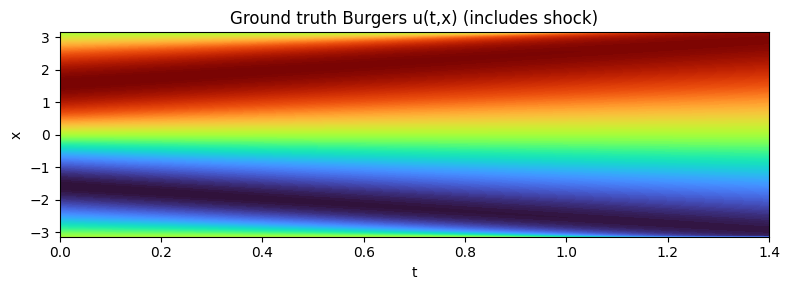

Dataset shapes: {'train_input': (1770, 2), 'train_label': (1770, 1), 'test_input': (442, 2), 'test_label': (442, 1)}
Feature count F = 2
checkpoint directory created: ./model
saving model version 0.0
step     0 | train 0.0128020523 | test 0.0099452389 | roll_train 0.0000003261 | roll_test 0.0000000000
step     1 | train 0.0099018663 | test 0.0080603315 | roll_train 0.0000004486 | roll_test 0.0000000000
step     2 | train 0.0093818279 | test 0.0078924755 | roll_train 0.0000004942 | roll_test 0.0000000000
step     3 | train 0.0089707207 | test 0.0088067222 | roll_train 0.0000005602 | roll_test 0.0000000000
step     4 | train 0.0088374084 | test 0.0081799617 | roll_train 0.0000005711 | roll_test 0.0000000000
step     5 | train 0.0088263638 | test 0.0079481388 | roll_train 0.0000005638 | roll_test 0.0000000000
step     6 | train 0.0088249007 | test 0.0080210231 | roll_train 0.0000005715 | roll_test 0.0000000000
step     7 | train 0.0088195670 | test 0.0082947295 | roll_train 0.0000005581 |

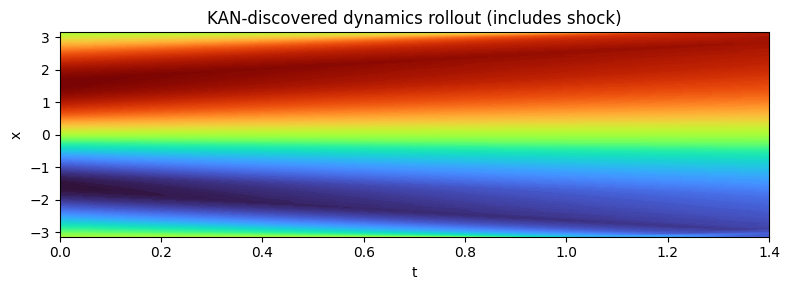

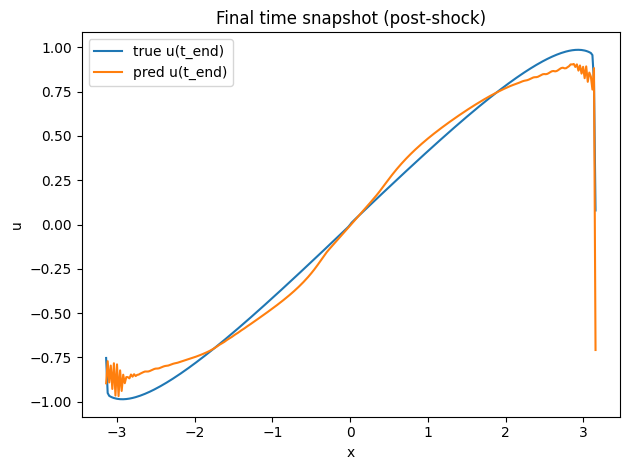


Feature order:
00: $u$
01: $u_x$
02: $uu_x$


In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from kan import KAN

# -----------------------
# Reproducibility / device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
print("Device:", device)

# ============================================================
# 1) Inviscid Burgers with shock:
#    u_t + u u_x = 0, periodic domain.
#    We'll integrate PAST shock time (sin initial shock ~ t=1).
#    Ground truth via MOL + Rusanov flux (shock-capturing).
# ============================================================

# Spatial grid
x_min, x_max = -np.pi, np.pi
dx = 0.02
x = np.arange(x_min, x_max + dx, dx)
Nx = len(x)

# Time grid (go beyond shock time)
t0, t1 = 0.0, 1.4
dt = 0.002
t = np.linspace(t0, t1, int(round((t1 - t0) / dt)) + 1)

# Initial condition
u0_np = np.sin(x).astype(np.float64)

def flux(u):
    return 0.5 * u**2

def burgers_rhs(_t: float, u: np.ndarray) -> np.ndarray:
    # Rusanov flux, periodic BCs
    uL = u
    uR = np.roll(u, -1)
    fL = flux(uL)
    fR = flux(uR)
    a = np.maximum(np.abs(uL), np.abs(uR))
    F_iphalf = 0.5 * (fL + fR) - 0.5 * a * (uR - uL)
    F_imhalf = np.roll(F_iphalf, 1)
    dudt = -(F_iphalf - F_imhalf) / dx
    return dudt

print("Generating Burgers data with shock (SciPy RK45)...")
sol = solve_ivp(
    burgers_rhs, (t0, t1), u0_np,
    t_eval=t, method="RK45",
    rtol=1e-7, atol=1e-9
)
if not sol.success:
    raise RuntimeError(sol.message)

U_true = sol.y.T.astype(np.float32)  # (Nt, Nx)
Nt = U_true.shape[0]

# visualize ground truth
plt.figure(figsize=(8,3))
plt.contourf(t, x, U_true.T, levels=201, cmap="turbo")
plt.xlabel("t"); plt.ylabel("x")
plt.title("Ground truth Burgers u(t,x) (includes shock)")
plt.tight_layout()
plt.show()

# ============================================================
# 2) Shock-robust spatial derivative: TVD minmod slope
#    This avoids exploding gradients/features near discontinuities.
# ============================================================

def minmod(a, b):
    # elementwise minmod
    return 0.5 * (torch.sign(a) + torch.sign(b)) * torch.minimum(torch.abs(a), torch.abs(b))

def tvd_ux(u, dx):
    """
    u: (B,Nx) or (Nx,)
    returns ux: same shape
    periodic boundaries via roll
    """
    if u.dim() == 1:
        u = u.unsqueeze(0)  # (1,Nx)
    up = torch.roll(u, shifts=-1, dims=1)
    um = torch.roll(u, shifts=+1, dims=1)
    du_f = (up - u) / dx
    du_b = (u - um) / dx
    ux = minmod(du_b, du_f)  # limited slope
    return ux

# ============================================================
# 3) Sparse supervision snapshots (including post-shock times)
#    We'll mimic your KS approach: u_t via forward diff between snapshots.
# ============================================================

# Choose snapshot times that span pre- and post-shock
t_train = np.array([0.0, 0.4, 0.8, 1.0, 1.1, 1.2, 1.3, 1.4], dtype=np.float32)

def time_to_index(tt, dt, t0=0.0):
    return int(round((float(tt) - float(t0)) / float(dt)))

train_indices = [time_to_index(tt, dt, t0=t0) for tt in t_train]
if max(train_indices) >= Nt:
    raise ValueError("t_train contains times outside the generated time grid.")

X_train_np = U_true[train_indices, :]  # (K, Nx)
K = X_train_np.shape[0]

# build u_t labels by forward difference across snapshot segments
X_snap = torch.tensor(X_train_np, dtype=torch.float32, device=device)  # (K,Nx)
t_snap = torch.tensor(t_train,    dtype=torch.float32, device=device)  # (K,)

dt_seg = (t_snap[1:] - t_snap[:-1]).unsqueeze(1)  # (K-1,1)
U_k    = X_snap[:-1]                              # (K-1,Nx)
Ut_k   = (X_snap[1:] - X_snap[:-1]) / dt_seg      # (K-1,Nx)

# compute shock-robust ux for U_k
ux_k = tvd_ux(U_k, dx)  # (K-1,Nx)

# ============================================================
# 4) Build a simple Burgers library per grid point
#    True PDE: u_t + u u_x = 0  -> u_t = - u u_x
#    Features: [1, u, u_x, u*u_x]
# ============================================================

def build_burgers_library(u, ux):
    """
    u, ux: torch tensors (B,Nx)
    returns Theta: (B*Nx, F)
    """
    feats = [
        #torch.ones_like(u),  # 1
        u,                   # u
        ux,                  # u_x
        u * ux               # u*u_x
    ]
    Theta = torch.stack(feats, dim=-1)  # (B,Nx,F)
    B, N, F = Theta.shape
    return Theta.reshape(B*N, F)

def ddx(u, dx=0.02):
    """
    u: (B, Nx) or (Nx,)
    returns du/dx with same shape
    """
    return (torch.roll(u, shifts=-1, dims=-1) - torch.roll(u, shifts=1, dims=-1)) / (2*dx)

def build_burgers_library(u, ux=None):
    """
    u: (B,Nx)
    returns Theta: (B*Nx, F)
    """
    f = 0.5 * u**2                  # flux
    fx = ddx(f)                     # you provide ddx, same scheme you use for ux
    feats = [
        u,                          # optional (lets model learn offsets/biases)
        fx,                         # d/dx (u^2/2)
    ]
    Theta = torch.stack(feats, dim=-1)
    B, N, F = Theta.shape
    return Theta.reshape(B*N, F)

Theta = build_burgers_library(U_k, ux_k)    # ( (K-1)*Nx, F )
y = Ut_k.reshape(-1, 1)                     # ( (K-1)*Nx, 1 )

# normalize features (helps KAN training a lot)
X_mean = Theta.mean(dim=0, keepdim=True)
X_std  = Theta.std(dim=0, keepdim=True) + 1e-8
Theta_n = (Theta - X_mean) / X_std

# train/test split over point samples
N = Theta_n.shape[0]
perm = torch.randperm(N, device=device)
test_frac = 0.2
N_test = max(1, int(test_frac * N))
test_idx = perm[:N_test]
train_idx = perm[N_test:]

dataset = {
    "train_input": Theta_n[train_idx],
    "train_label": y[train_idx],
    "test_input":  Theta_n[test_idx],
    "test_label":  y[test_idx],
}

print("Dataset shapes:", {k: tuple(v.shape) for k, v in dataset.items()})
print("Feature count F =", Theta_n.shape[1])

# ============================================================
# 5) Rollout windows for integration loss (like your KS setup)
#    We'll sample short windows from full U_true.
# ============================================================

rollout_horizon = 10  # number of steps in a window (short is important for shocks)
H = int(rollout_horizon)

U_series = torch.tensor(U_true, dtype=torch.float32, device=device)  # (Nt,Nx)
t_series = torch.tensor(t,      dtype=torch.float32, device=device)  # (Nt,)

def sample_windows(U, T, H, n_windows, seed=0):
    g = torch.Generator(device=U.device)
    g.manual_seed(seed)
    max_start = U.shape[0] - (H + 1)
    starts = torch.randint(0, max_start + 1, (n_windows,), generator=g, device=U.device)
    trj_u = torch.stack([U[s:s+H+1] for s in starts], dim=0)  # (n_windows,H+1,Nx)
    trj_t = torch.stack([T[s:s+H+1] for s in starts], dim=0)  # (n_windows,H+1)
    return trj_u, trj_t

n_train_trj = 1
n_test_trj  = 1

train_u_trj, train_t_trj = sample_windows(U_series, t_series, H, n_train_trj, seed=1)
test_u_trj,  test_t_trj  = sample_windows(U_series, t_series, H, n_test_trj,  seed=2)

dataset["train_traj"] = train_u_trj          # (n_train_trj, H+1, state_dim)
dataset["train_t"]    = train_t_trj          # (n_train_trj, H+1)

# ============================================================
# 6) KAN model: (F -> 1) predicts u_t at each grid point
# ============================================================

n_features = int(Theta_n.shape[1])
rbf = lambda x: torch.exp(-(x**2))
kan_pde = KAN(width=[n_features, 1], grid=7, k=3, base_fun=rbf, seed=0).to(device)

# ============================================================
# 7) Dynamics function for rollout: u -> u_t
#    Computes ux (TVD), builds Theta, normalizes, applies KAN, reshapes.
# ============================================================

def dynamics_fn(u):
    """
    u: (B,Nx) or (Nx,)
    returns u_t: (B,Nx)
    """
    if u.dim() == 1:
        u = u.unsqueeze(0)
    ux = tvd_ux(u, dx)
    Theta = build_burgers_library(u, ux)          # (B*Nx,F)
    Theta_n = (Theta - X_mean) / X_std
    ut = kan_pde(Theta_n)
    if ut.dim() == 2 and ut.shape[1] == 1:
        ut = ut[:, 0]
    ut = ut.reshape(u.shape[0], u.shape[1])
    return ut

def dynamics_training_fn(u_state):
    """
    u_state: (B, Nx)  state for each trajectory batch at a time
    returns: (B, Nx)  time derivative
    """
    if u_state.dim() == 1:
        u_state = u_state.unsqueeze(0)

    ux = tvd_ux(u_state, dx)                    # (B,Nx)
    Theta = build_burgers_library(u_state, ux)  # (B*Nx, F)

    Theta_n = (Theta - X_mean) / X_std          # normalize (broadcast)
    #Theta_n = Theta
    ut = kan_pde(Theta_n)                       # (B*Nx,1)
    ut = ut[:, 0].reshape(u_state.shape[0], u_state.shape[1])  # (B,Nx)
    return ut

# ============================================================
# 8) Rollout integrator (RK4) on fixed dt
# ============================================================

def rk4_step(u, dt):
    k1 = dynamics_fn(u)
    k2 = dynamics_fn(u + 0.5*dt*k1)
    k3 = dynamics_fn(u + 0.5*dt*k2)
    k4 = dynamics_fn(u + dt*k3)
    return u + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


# # ============================================================
# # 10) Evaluate: full rollout from u0 to t1 using learned dynamics
# # ============================================================
#kan_pde.fit(dataset, steps=25)
fit(kan_pde,
    dataset,
    steps=50,
    rollout_weight=10.9,          # enable rollout loss
    rollout_horizon=3,#10,        # None => full horizon within provided train_t
    dynamics_fn=dynamics_training_fn,
    integrator="rk4",
)

with torch.no_grad():
    u_pred = torch.tensor(u0_np.astype(np.float32), device=device).unsqueeze(0)  # (1,Nx)
    U_pred = [u_pred.squeeze(0).detach().cpu().numpy()]
    for k in range(Nt-1):
        dt_k = float(t[k+1] - t[k])
        u_pred = rk4_step(u_pred, torch.tensor([[dt_k]], device=device))
        U_pred.append(u_pred.squeeze(0).detach().cpu().numpy())

U_pred = np.stack(U_pred, axis=0)  # (Nt,Nx)

# Contour comparison
plt.figure(figsize=(8,3))
plt.contourf(t, x, U_pred.T, levels=201, cmap="turbo")
plt.xlabel("t"); plt.ylabel("x")
plt.title("KAN-discovered dynamics rollout (includes shock)")
plt.tight_layout()
plt.show()

# Final-time line plot
plt.figure()
plt.plot(x, U_true[-1], label="true u(t_end)")
plt.plot(x, U_pred[-1], label="pred u(t_end)")
plt.xlabel("x"); plt.ylabel("u")
plt.title("Final time snapshot (post-shock)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 11) Quick coefficient sanity check (optional):
#     If the learned model is close, symbolic extraction often yields ~ -u*u_x
# ============================================================

print("\nFeature order:")
feat_names = [r"$u$", r"$u_x$", r"$uu_x$"]
for i, nm in enumerate(feat_names):
    print(f"{i:02d}: {nm}")



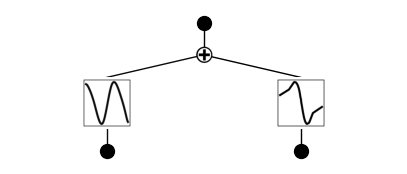

In [10]:
model = kan_pde
model.save_act=True
_ = model(dataset["train_input"])
model.plot(beta=10)#, in_vars=in_vars_latex, out_vars=out_vars_latex)

# plt.savefig(
#     "figs/ks_model.pdf",
#     format="pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from kan import KAN

# -----------------------
# Reproducibility / device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
print("Device:", device)

# ============================================================
# 1) Inviscid Burgers with shock:
#    u_t + u u_x = 0, periodic domain.
#    We'll integrate PAST shock time (sin initial shock ~ t=1).
#    Ground truth via MOL + Rusanov flux (shock-capturing).
# ============================================================

# Spatial grid
x_min, x_max = -np.pi, np.pi
dx = 0.02
x = np.arange(x_min, x_max + dx, dx)
Nx = len(x)

# Time grid (go beyond shock time)
t0, t1 = 0.0, 1.4
dt = 0.002
t = np.linspace(t0, t1, int(round((t1 - t0) / dt)) + 1)

# Initial condition
u0_np = np.sin(x).astype(np.float64)

def flux(u):
    return 0.5 * u**2

def burgers_rhs(_t: float, u: np.ndarray) -> np.ndarray:
    # Rusanov flux, periodic BCs
    uL = u
    uR = np.roll(u, -1)
    fL = flux(uL)
    fR = flux(uR)
    a = np.maximum(np.abs(uL), np.abs(uR))
    F_iphalf = 0.5 * (fL + fR) - 0.5 * a * (uR - uL)
    F_imhalf = np.roll(F_iphalf, 1)
    dudt = -(F_iphalf - F_imhalf) / dx
    return dudt

print("Generating Burgers data with shock (SciPy RK45)...")
sol = solve_ivp(
    burgers_rhs, (t0, t1), u0_np,
    t_eval=t, method="RK45",
    rtol=1e-7, atol=1e-9
)
if not sol.success:
    raise RuntimeError(sol.message)

U_true = sol.y.T.astype(np.float32)  # (Nt, Nx)
Nt = U_true.shape[0]

# visualize ground truth
plt.figure(figsize=(8,3))
plt.contourf(t, x, U_true.T, levels=201, cmap="turbo")
plt.xlabel("t"); plt.ylabel("x")
plt.title("Ground truth Burgers u(t,x) (includes shock)")
plt.tight_layout()
plt.show()

# ============================================================
# 2) Shock-robust spatial derivative: TVD minmod slope
#    This avoids exploding gradients/features near discontinuities.
# ============================================================

def minmod(a, b):
    # elementwise minmod
    return 0.5 * (torch.sign(a) + torch.sign(b)) * torch.minimum(torch.abs(a), torch.abs(b))

def tvd_ux(u, dx):
    """
    u: (B,Nx) or (Nx,)
    returns ux: same shape
    periodic boundaries via roll
    """
    if u.dim() == 1:
        u = u.unsqueeze(0)  # (1,Nx)
    up = torch.roll(u, shifts=-1, dims=1)
    um = torch.roll(u, shifts=+1, dims=1)
    du_f = (up - u) / dx
    du_b = (u - um) / dx
    ux = minmod(du_b, du_f)  # limited slope
    return ux

# Choose snapshot times that span pre- and post-shock
t_train = np.array([0.0, 0.4, 0.8, 1.0, 1.1, 1.2, 1.3, 1.4], dtype=np.float32)
#t_train = np.arange(0.0, T_train + dt, dt).astype(np.float32)

def time_to_index(tt, dt, t0=0.0):
    return int(round((float(tt) - float(t0)) / float(dt)))

train_indices = [time_to_index(tt, dt, t0=t0) for tt in t_train]
if max(train_indices) >= Nt:
    raise ValueError("t_train contains times outside the generated time grid.")

X_train_np = U_true[train_indices, :]  # (K, Nx)
K = X_train_np.shape[0]

# build u_t labels by forward difference across snapshot segments
X_snap = torch.tensor(X_train_np, dtype=torch.float32, device=device)  # (K,Nx)
t_snap = torch.tensor(t_train,    dtype=torch.float32, device=device)  # (K,)

dt_seg = (t_snap[1:] - t_snap[:-1]).unsqueeze(1)  # (K-1,1)
U_k    = X_snap[:-1]                              # (K-1,Nx)
Ut_k   = (X_snap[1:] - X_snap[:-1]) / dt_seg      # (K-1,Nx)

# compute shock-robust ux for U_k
ux_k = tvd_ux(U_k, dx)  # (K-1,Nx)

# ============================================================
# 4) Build a simple Burgers library per grid point
#    True PDE: u_t + u u_x = 0  -> u_t = - u u_x
#    Features: [1, u, u_x, u*u_x]
# ============================================================

def build_burgers_library(u, ux):
    """
    u, ux: torch tensors (B,Nx)
    returns Theta: (B*Nx, F)
    """
    feats = [
        #torch.ones_like(u),  # 1
        u,                   # u
        ux,                  # u_x
        u * ux               # u*u_x
    ]
    Theta = torch.stack(feats, dim=-1)  # (B,Nx,F)
    B, N, F = Theta.shape
    return Theta.reshape(B*N, F)

def ddx(u, dx=0.02):
    """
    u: (B, Nx) or (Nx,)
    returns du/dx with same shape
    """
    return (torch.roll(u, shifts=-1, dims=-1) - torch.roll(u, shifts=1, dims=-1)) / (2*dx)

def build_burgers_library(u, ux=None):
    """
    u: (B,Nx)
    returns Theta: (B*Nx, F)
    """
    f = 0.5 * u**2                  # flux
    fx = ddx(f)                     # you provide ddx, same scheme you use for ux
    feats = [
        u,                          # optional (lets model learn offsets/biases)
        fx,                         # d/dx (u^2/2)
    ]
    Theta = torch.stack(feats, dim=-1)
    B, N, F = Theta.shape
    return Theta.reshape(B*N, F)

def build_burgers_library(u, ux=None):
    f = 0.5 * u**2
    fx = tvd_ux(f, dx)      # use limiter on flux!
    feats = [f, fx]         # or [u, fx] if you want
    Theta = torch.stack(feats, dim=-1)
    B, N, F = Theta.shape
    return Theta.reshape(B*N, F)

Theta = build_burgers_library(U_k, ux_k)    # ( (K-1)*Nx, F )
y = Ut_k.reshape(-1, 1)                     # ( (K-1)*Nx, 1 )

# normalize features (helps KAN training a lot)
X_mean = Theta.mean(dim=0, keepdim=True)
X_std  = Theta.std(dim=0, keepdim=True) + 1e-8
Theta_n = (Theta - X_mean) / X_std

# train/test split over point samples
N = Theta_n.shape[0]
perm = torch.randperm(N, device=device)
test_frac = 0.2
N_test = max(1, int(test_frac * N))
test_idx = perm[:N_test]
train_idx = perm[N_test:]

dataset = {
    "train_input": Theta_n[train_idx],
    "train_label": y[train_idx],
    "test_input":  Theta_n[test_idx],
    "test_label":  y[test_idx],
}

print("Dataset shapes:", {k: tuple(v.shape) for k, v in dataset.items()})
print("Feature count F =", Theta_n.shape[1])

# ============================================================
# 5) Rollout windows for integration loss (like your KS setup)
#    We'll sample short windows from full U_true.
# ============================================================

rollout_horizon = 3  # number of steps in a window (short is important for shocks)
H = int(rollout_horizon)

U_series = torch.tensor(U_true, dtype=torch.float32, device=device)  # (Nt,Nx)
t_series = torch.tensor(t,      dtype=torch.float32, device=device)  # (Nt,)

def sample_windows(U, T, H, n_windows, seed=0):
    g = torch.Generator(device=U.device)
    g.manual_seed(seed)
    max_start = U.shape[0] - (H + 1)
    starts = torch.randint(0, max_start + 1, (n_windows,), generator=g, device=U.device)
    trj_u = torch.stack([U[s:s+H+1] for s in starts], dim=0)  # (n_windows,H+1,Nx)
    trj_t = torch.stack([T[s:s+H+1] for s in starts], dim=0)  # (n_windows,H+1)
    return trj_u, trj_t

n_train_trj = 128
n_test_trj  = 1

train_u_trj, train_t_trj = sample_windows(U_series, t_series, H, n_train_trj, seed=1)
test_u_trj,  test_t_trj  = sample_windows(U_series, t_series, H, n_test_trj,  seed=2)

dataset["train_traj"] = train_u_trj          # (n_train_trj, H+1, state_dim)
dataset["train_t"]    = train_t_trj          # (n_train_trj, H+1)

# ============================================================
# 6) KAN model: (F -> 1) predicts u_t at each grid point
# ============================================================

n_features = int(Theta_n.shape[1])
rbf = lambda x: torch.exp(-(x**2))
kan_pde = KAN(width=[n_features, 1], grid=50, k=30, base_fun=rbf, seed=0).to(device)

# ============================================================
# 7) Dynamics function for rollout: u -> u_t
#    Computes ux (TVD), builds Theta, normalizes, applies KAN, reshapes.
# ============================================================

def dynamics_fn(u):
    """
    u: (B,Nx) or (Nx,)
    returns u_t: (B,Nx)
    """
    if u.dim() == 1:
        u = u.unsqueeze(0)
    ux = tvd_ux(u, dx)
    Theta = build_burgers_library(u, ux)          # (B*Nx,F)
    Theta_n = (Theta - X_mean) / X_std
    ut = kan_pde(Theta_n)
    if ut.dim() == 2 and ut.shape[1] == 1:
        ut = ut[:, 0]
    ut = ut.reshape(u.shape[0], u.shape[1])
    return ut

def dynamics_training_fn(u_state):
    """
    u_state: (B, Nx)  state for each trajectory batch at a time
    returns: (B, Nx)  time derivative
    """
    if u_state.dim() == 1:
        u_state = u_state.unsqueeze(0)

    ux = tvd_ux(u_state, dx)                    # (B,Nx)
    Theta = build_burgers_library(u_state, ux)  # (B*Nx, F)

    Theta_n = (Theta - X_mean) / X_std          # normalize (broadcast)
    #Theta_n = Theta
    ut = kan_pde(Theta_n)                       # (B*Nx,1)
    ut = ut[:, 0].reshape(u_state.shape[0], u_state.shape[1])  # (B,Nx)
    return ut

# ============================================================
# 8) Rollout integrator (RK4) on fixed dt
# ============================================================

def rk4_step(u, dt):
    k1 = dynamics_fn(u)
    k2 = dynamics_fn(u + 0.5*dt*k1)
    k3 = dynamics_fn(u + 0.5*dt*k2)
    k4 = dynamics_fn(u + dt*k3)
    return u + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


# # ============================================================
# # 10) Evaluate: full rollout from u0 to t1 using learned dynamics
# # ============================================================
#losses = kan_pde.fit(dataset, opt="Adam", steps=100)
results = fit(kan_pde,
    dataset,
    steps=100,
    rollout_weight=1.0,          # enable rollout loss
    rollout_horizon=3,#10,        # None => full horizon within provided train_t
    dynamics_fn=dynamics_training_fn,
    integrator="rk4",
)

with torch.no_grad():
    u_pred = torch.tensor(u0_np.astype(np.float32), device=device).unsqueeze(0)  # (1,Nx)
    U_pred = [u_pred.squeeze(0).detach().cpu().numpy()]
    for k in range(Nt-1):
        dt_k = float(t[k+1] - t[k])
        u_pred = rk4_step(u_pred, torch.tensor([[dt_k]], device=device))
        U_pred.append(u_pred.squeeze(0).detach().cpu().numpy())

U_pred = np.stack(U_pred, axis=0)  # (Nt,Nx)

# Contour comparison
plt.figure(figsize=(8,3))
plt.contourf(t, x, U_pred.T, levels=201, cmap="turbo")
plt.xlabel("t"); plt.ylabel("x")
plt.title("KAN-discovered dynamics rollout (includes shock)")
plt.tight_layout()
plt.show()

# Final-time line plot
plt.figure()
plt.plot(x, U_true[-1], label="true u(t_end)")
plt.plot(x, U_pred[-1], label="pred u(t_end)")
plt.xlabel("x"); plt.ylabel("u")
plt.title("Final time snapshot (post-shock)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from kan import KAN

# -----------------------
# Reproducibility / device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
print("Device:", device)

# ============================================================
# 1) Inviscid Burgers with shock:
#    u_t + u u_x = 0, periodic domain.
#    We'll integrate PAST shock time (sin initial shock ~ t=1).
#    Ground truth via MOL + Rusanov flux (shock-capturing).
# ============================================================

# Spatial grid
x_min, x_max = -np.pi, np.pi
dx = 0.02
x = np.arange(x_min, x_max + dx, dx)
Nx = len(x)

# Time grid (go beyond shock time)
t0, t1 = 0.0, 1.4
#t1 = 3.0   # or 4.0 for random faurier modes
dt = 0.002
t = np.linspace(t0, t1, int(round((t1 - t0) / dt)) + 1)

# Initial condition
# u(x, 0) =sin(x)
#u0_np = np.sin(x).astype(np.float64)

K = 20                      # number of Fourier modes
p = 1.5                     # spectral decay
a = np.random.randn(K) * (np.arange(1, K+1) ** (-p))
phi = 2*np.pi*np.random.rand(K)

# u0_np = sum(
#     a[k] * np.sin((k+1)*x + phi[k]) for k in range(K)
# ).astype(np.float64)
u0_np = np.sin(x).astype(np.float64)


def flux(u):
    return 0.5 * u**2

def burgers_rhs(_t: float, u: np.ndarray) -> np.ndarray:
    # Rusanov flux, periodic BCs
    uL = u
    uR = np.roll(u, -1)
    fL = flux(uL)
    fR = flux(uR)
    a = np.maximum(np.abs(uL), np.abs(uR))
    F_iphalf = 0.5 * (fL + fR) - 0.5 * a * (uR - uL)
    F_imhalf = np.roll(F_iphalf, 1)
    dudt = -(F_iphalf - F_imhalf) / dx
    return dudt

print("Generating Burgers data with shock (SciPy RK45)...")
sol = solve_ivp(
    burgers_rhs, (t0, t1), u0_np,
    t_eval=t, method="RK45",
    rtol=1e-7, atol=1e-9
)
if not sol.success:
    raise RuntimeError(sol.message)

U_true = sol.y.T.astype(np.float32)  # (Nt, Nx)
Nt = U_true.shape[0]

# visualize ground truth
plt.figure(figsize=(8,3))
plt.contourf(t, x, U_true.T, levels=201, cmap="turbo")
plt.xlabel("t"); plt.ylabel("x")
plt.title("Ground truth Burgers u(t,x) (includes shock)")
plt.tight_layout()
plt.show()

# ============================================================
# 2) Shock-robust spatial derivative: TVD minmod slope
#    This avoids exploding gradients/features near discontinuities.
# ============================================================

def minmod(a, b):
    # elementwise minmod
    return 0.5 * (torch.sign(a) + torch.sign(b)) * torch.minimum(torch.abs(a), torch.abs(b))

def tvd_ux(u, dx):
    """
    u: (B,Nx) or (Nx,)
    returns ux: same shape
    periodic boundaries via roll
    """
    if u.dim() == 1:
        u = u.unsqueeze(0)  # (1,Nx)
    up = torch.roll(u, shifts=-1, dims=1)
    um = torch.roll(u, shifts=+1, dims=1)
    du_f = (up - u) / dx
    du_b = (u - um) / dx
    ux = minmod(du_b, du_f)  # limited slope
    return ux

# ============================================================
# 3) Sparse supervision snapshots (including post-shock times)
#    We'll mimic your KS approach: u_t via forward diff between snapshots.
# ============================================================

# Choose snapshot times that span pre- and post-shock
t_train = np.array([0.0, 0.4, 0.8, 1.0, 1.1, 1.2, 1.3, 1.4], dtype=np.float32)
#t_train = np.array([0.0, 0.4, 0.8, 1.0, 1.2, 1.4, 1.8, 2.2, 2.6, 3.0], dtype=np.float32)


def time_to_index(tt, dt, t0=0.0):
    return int(round((float(tt) - float(t0)) / float(dt)))

train_indices = [time_to_index(tt, dt, t0=t0) for tt in t_train]
if max(train_indices) >= Nt:
    raise ValueError("t_train contains times outside the generated time grid.")

X_train_np = U_true[train_indices, :]  # (K, Nx)
K = X_train_np.shape[0]

# build u_t labels by forward difference across snapshot segments
X_snap = torch.tensor(X_train_np, dtype=torch.float32, device=device)  # (K,Nx)
t_snap = torch.tensor(t_train,    dtype=torch.float32, device=device)  # (K,)

dt_seg = (t_snap[1:] - t_snap[:-1]).unsqueeze(1)  # (K-1,1)
U_k    = X_snap[:-1]                              # (K-1,Nx)
Ut_k   = (X_snap[1:] - X_snap[:-1]) / dt_seg      # (K-1,Nx)

#### new uk
stride_t = 5
X_snap = U_k[::stride_t]                 # (Nt/stride, Nx)
dt_snap = dt * stride_t
U_k  = X_snap[:-1]
Ut_k = (X_snap[1:] - X_snap[:-1]) / dt_snap
###

# compute shock-robust ux for U_k
ux_k = tvd_ux(U_k, dx)  # (K-1,Nx)

# ============================================================
# 4) Build a simple Burgers library per grid point
#    True PDE: u_t + u u_x = 0  -> u_t = - u u_x
#    Features: [1, u, u_x, u*u_x]
# ============================================================

def build_burgers_library(u, ux):
    """
    u, ux: torch tensors (B,Nx)
    returns Theta: (B*Nx, F)
    """
    feats = [
        #torch.ones_like(u),  # 1
        u,                   # u
        ux,                  # u_x
        u * ux               # u*u_x
    ]
    Theta = torch.stack(feats, dim=-1)  # (B,Nx,F)
    B, N, F = Theta.shape
    return Theta.reshape(B*N, F)

def ddx(u, dx=0.02):
    """
    u: (B, Nx) or (Nx,)
    returns du/dx with same shape
    """
    return (torch.roll(u, shifts=-1, dims=-1) - torch.roll(u, shifts=1, dims=-1)) / (2*dx)

def _build_burgers_library(u, ux=None):
    """
    u: (B,Nx)
    returns Theta: (B*Nx, F)
    """
    f = 0.5 * u**2                  # flux
    fx = ddx(f)                     # you provide ddx, same scheme you use for ux
    feats = [
        u,                          # optional (lets model learn offsets/biases)
        ux,
        fx,                         # d/dx (u^2/2)
    ]
    Theta = torch.stack(feats, dim=-1)
    B, N, F = Theta.shape
    return Theta.reshape(B*N, F)

Theta = build_burgers_library(U_k, ux_k)    # ( (K-1)*Nx, F )
y = Ut_k.reshape(-1, 1)                     # ( (K-1)*Nx, 1 )

# normalize features (helps KAN training a lot)
X_mean = Theta.mean(dim=0, keepdim=True)
X_std  = Theta.std(dim=0, keepdim=True) + 1e-8
Theta_n = (Theta - X_mean) / X_std

# train/test split over point samples
N = Theta_n.shape[0]
perm = torch.randperm(N, device=device)
test_frac = 0.2
N_test = max(1, int(test_frac * N))
test_idx = perm[:N_test]
train_idx = perm[N_test:]

dataset = {
    "train_input": Theta_n[train_idx],
    "train_label": y[train_idx],
    "test_input":  Theta_n[test_idx],
    "test_label":  y[test_idx],
}

print("Dataset shapes:", {k: tuple(v.shape) for k, v in dataset.items()})
print("Feature count F =", Theta_n.shape[1])

# ============================================================
# 5) Rollout windows for integration loss (like your KS setup)
#    We'll sample short windows from full U_true.
# ============================================================

rollout_horizon = 10  # number of steps in a window (short is important for shocks)
H = int(rollout_horizon)

U_series = torch.tensor(U_true, dtype=torch.float32, device=device)  # (Nt,Nx)
t_series = torch.tensor(t,      dtype=torch.float32, device=device)  # (Nt,)

def sample_windows(U, T, H, n_windows, seed=0):
    g = torch.Generator(device=U.device)
    g.manual_seed(seed)
    max_start = U.shape[0] - (H + 1)
    starts = torch.randint(0, max_start + 1, (n_windows,), generator=g, device=U.device)
    trj_u = torch.stack([U[s:s+H+1] for s in starts], dim=0)  # (n_windows,H+1,Nx)
    trj_t = torch.stack([T[s:s+H+1] for s in starts], dim=0)  # (n_windows,H+1)
    return trj_u, trj_t

n_train_trj = 1
n_test_trj  = 1

train_u_trj, train_t_trj = sample_windows(U_series, t_series, H, n_train_trj, seed=1)
test_u_trj,  test_t_trj  = sample_windows(U_series, t_series, H, n_test_trj,  seed=2)

#dataset["train_traj"] = train_u_trj          # (n_train_trj, H+1, state_dim)
#dataset["train_t"]    = train_t_trj          # (n_train_trj, H+1)
dataset["train_traj"] = train_u_trj          # (n_train_trj, H+1, Nx)
dataset["train_t"]    = train_t_trj[0]       # (H+1,)  <- 1D shared time


# ============================================================
# 6) KAN model: (F -> 1) predicts u_t at each grid point
# ============================================================

n_features = int(Theta_n.shape[1])
rbf = lambda x: torch.exp(-(x**2))
kan_pde = KAN(width=[n_features, 1], grid=50, k=30, base_fun=rbf, seed=0).to(device)

# ============================================================
# 7) Dynamics function for rollout: u -> u_t
#    Computes ux (TVD), builds Theta, normalizes, applies KAN, reshapes.
# ============================================================

def dynamics_fn(u):
    """
    u: (B,Nx) or (Nx,)
    returns u_t: (B,Nx)
    """
    if u.dim() == 1:
        u = u.unsqueeze(0)
    ux = tvd_ux(u, dx)
    Theta = build_burgers_library(u, ux)          # (B*Nx,F)
    Theta_n = (Theta - X_mean) / X_std
    ut = kan_pde(Theta_n)
    if ut.dim() == 2 and ut.shape[1] == 1:
        ut = ut[:, 0]
    ut = ut.reshape(u.shape[0], u.shape[1])
    return ut

def dynamics_training_fn(u_state):
    """
    u_state: (B, Nx)  state for each trajectory batch at a time
    returns: (B, Nx)  time derivative
    """
    if u_state.dim() == 1:
        u_state = u_state.unsqueeze(0)

    ux = tvd_ux(u_state, dx)                    # (B,Nx)
    Theta = build_burgers_library(u_state, ux)  # (B*Nx, F)

    Theta_n = (Theta - X_mean) / X_std          # normalize (broadcast)
    #Theta_n = Theta
    ut = kan_pde(Theta_n)                       # (B*Nx,1)
    ut = ut[:, 0].reshape(u_state.shape[0], u_state.shape[1])  # (B,Nx)
    return ut

# ============================================================
# 8) Rollout integrator (RK4) on fixed dt
# ============================================================

def rk4_step(u, dt):
    k1 = dynamics_fn(u)
    k2 = dynamics_fn(u + 0.5*dt*k1)
    k3 = dynamics_fn(u + 0.5*dt*k2)
    k4 = dynamics_fn(u + dt*k3)
    return u + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


# # ============================================================
# # 10) Evaluate: full rollout from u0 to t1 using learned dynamics
# # ============================================================
losses = kan_pde.fit(dataset,
                     #opt="Adam",
                     #lamb=0.000001,
                     singularity_avoiding=True,
                     steps=200)
results = fit(kan_pde,
    dataset,
    steps=300,
    lamb=0.00000000,
    rollout_weight=0.1, #10.0,          # enable rollout loss
    rollout_horizon=1,#10,        # None => full horizon within provided train_t
    #rollout_weight=50.0,
    traj_batch=1,
    singularity_avoiding=False,
    dynamics_fn=dynamics_training_fn,
    #opt='Adam',
    integrator='euler',#"rk4",
)
# results = fit(
#     kan_pde, dataset,
#     opt="Adam",
#     lr=1e-3,
#     steps=50,
#     rollout_weight=0.0,   # turn off rollout
# )


with torch.no_grad():
    u_pred = torch.tensor(u0_np.astype(np.float32), device=device).unsqueeze(0)  # (1,Nx)
    U_pred = [u_pred.squeeze(0).detach().cpu().numpy()]
    for k in range(Nt-1):
        dt_k = float(t[k+1] - t[k])
        u_pred = rk4_step(u_pred, torch.tensor([[dt_k]], device=device))
        U_pred.append(u_pred.squeeze(0).detach().cpu().numpy())

U_pred = np.stack(U_pred, axis=0)  # (Nt,Nx)

# Contour comparison
plt.figure(figsize=(8,3))
plt.contourf(t, x, U_pred.T, levels=201, cmap="turbo")
plt.xlabel("t"); plt.ylabel("x")
plt.title("KAN-discovered dynamics rollout (includes shock)")
plt.tight_layout()
plt.show()

# Final-time line plot
plt.figure()
plt.plot(x, U_true[-1], label="true u(t_end)")
plt.plot(x, U_pred[-1], label="pred u(t_end)")
plt.xlabel("x"); plt.ylabel("u")
plt.title("Final time snapshot (post-shock)")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
import sympy as sp
import sympy as sp
from sympy import Eq
from sympy.printing.latex import latex
from IPython.display import display, Math

model = kan_pde
model.unfix_symbolic_all()
model.save_act = True
_ = model(dataset["train_input"])
model.prune()

model_sym, rep = robust_auto_symbolic(
    model,
    simple_lib=['x','x^2','x^3','0'],   # or pass your SYMBOLIC_LIB dict if your KAN expects dict
    complex_lib=['x','x^2','0'],
    r2_threshold=0.5,
    weight_simple=0.5,
    keep="topk",
    topk_edges=64,
    max_total_complexity=120,           # optional
    verbose=1,
    inplace=True
)

raw = model_sym.symbolic_formula()
print("Symbolic formula extracted.")
exprs_raw, vars_ = model.symbolic_formula()

n_in = int(model.width_in[0])

in_vars_latex_full = [
    #r"$1$",
    r"$u$",
    r"$\frac{\partial}{\partial t}\left(\frac{u^2}{2}\right)$",
    r"$u_x$",
    r"$u_{xx}$",
    r"$u_{xxxx}$",
    r"$u^2$",
    r"$u^3$",
    r"$u_x^2$",
    r"$u_{xx}^2$",
    r"$u\,u_x$",
    r"$u\,u_{xx}$",
    r"$u\,u_{xxxx}$",
    r"$u_x\,u_{xx}$",
]
out_vars_latex = [r"$u_t$"]

u_sym, u_x_sym, u_xx_sym, u_xxxx_sym = sp.symbols("u uu_xx uu_xx u_xxxx")
feature_syms_full = [
    #sp.Integer(1),
    u_sym,
    u_x_sym,
    u_xx_sym,
    u_xxxx_sym,
    u_sym**2,
    u_sym**3,
    u_x_sym**2,
    u_xx_sym**2,
    u_sym*u_x_sym,
    u_sym*u_xx_sym,
    u_sym*u_xxxx_sym,
    u_x_sym*u_xx_sym,
]

if n_in > len(in_vars_latex_full):
    raise ValueError(
        f"Model expects {n_in} inputs but only {len(in_vars_latex_full)} labels were provided. "
        "Update in_vars_latex_full/feature_syms_full to match your dataset columns."
    )

in_vars_latex = in_vars_latex_full[:n_in]
feature_syms  = feature_syms_full[:n_in]

sub_map = {vars_[i]: feature_syms[i] for i in range(n_in)}

def round_numbers(expr, places=3):
    repl = {}
    for a in expr.atoms(sp.Number):
        try:
            repl[a] = sp.Float(round(float(a), places))
        except Exception:
            pass
    return expr.xreplace(repl)

# Ensure we have a flat list of 3 expressions
# Some KAN versions return nested lists; handle both.
def flatten(obj):
    if isinstance(obj, (list, tuple)):
        out = []
        for it in obj:
            out.extend(flatten(it))
        return out
    return [obj]

exprs_list = flatten(exprs_raw)

# Substitute using vars_ (NOT free_symbols inference)
cleaned = []
for expr in exprs_list:
    if not hasattr(expr, "free_symbols"):
        continue
    expr_sub = expr.subs(sub_map)                 # <-- the key fix
    expr_sub = sp.together(sp.expand(expr_sub))
    expr_sub = round_numbers(expr_sub, 3)
    cleaned.append(expr_sub)

# Display
xd, yd, zd = sp.symbols(r"\dot{x} \dot{y} \dot{z}")
if len(cleaned) >= 3:
    display(Math(latex(Eq(xd, cleaned[0]))))
    display(Math(latex(Eq(yd, cleaned[1]))))
    display(Math(latex(Eq(zd, cleaned[2]))))
else:
    lines = []
    for k, ex in enumerate(cleaned):
        lines.append(latex(Eq(sp.Symbol(f"u_t"), ex)))
    display(Math(r"\begin{cases}" + r"\\ ".join(lines) + r"\end{cases}"))

print("\nInviscid Burgers' equation:")
print("u_t + u u_x = 0")
print("="*60)

saving model version 0.14
saving model version 0.15
saving model version 0.16
saving model version 0.16
robust_auto_symbolic: total_edges=2, eligible(r2>=0.5)=1, kept=1, fixed=1, zeroed=1
Symbolic formula extracted.


<IPython.core.display.Math object>


Inviscid Burgers' equation:
u_t + u u_x = 0


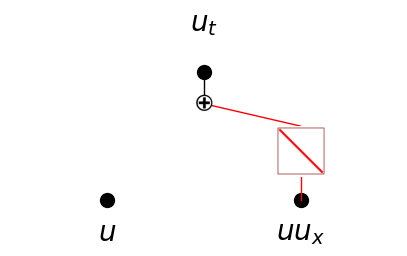

In [20]:
kan_pde.save_act = True
_ = kan_pde(dataset['train_input'])
#kan_pde = kan_pde.prune(node_th=0.185, edge_th=0.185)
#kan_pde = kan_pde.prune(node_th=0.185, edge_th=0.29)
kan_pde.plot(in_vars=[r"$u$", r"$uu_x$"], out_vars=[r"$u_t$"])
plt.savefig(
    "figs/burgers_model.svg",
    format="svg",
    dpi=300,
    bbox_inches="tight"
)

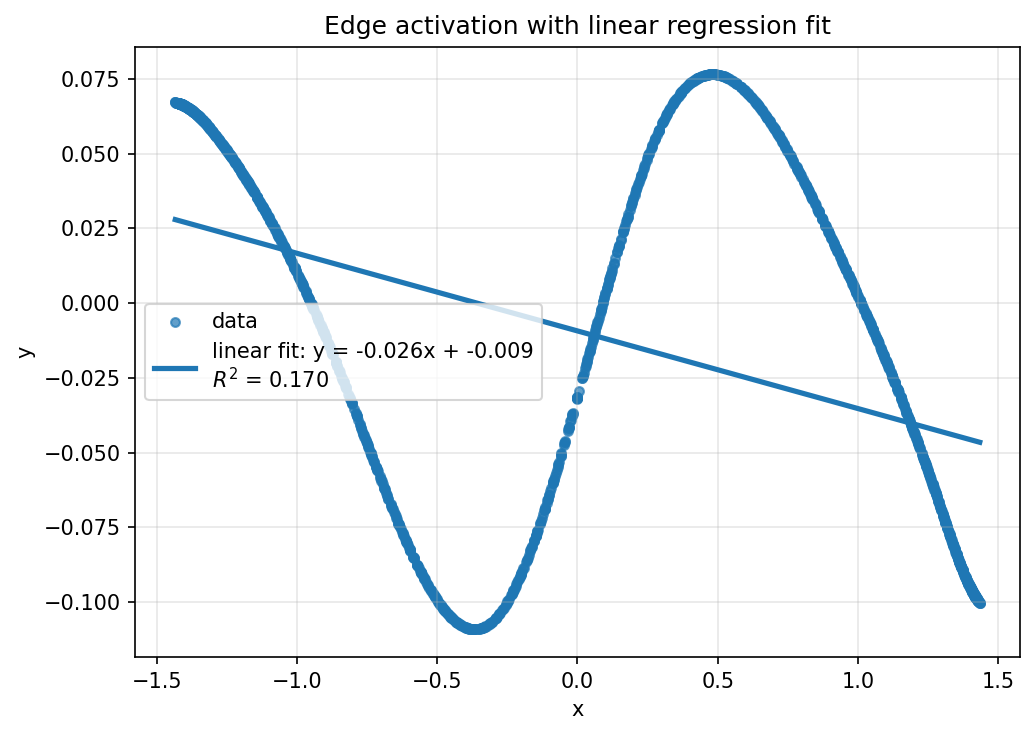

slope m = -0.025984
intercept b = -0.009301
R^2 = 0.169942


In [12]:
kan_pde.save_act = True
kan_pde(dataset['train_input'])
x, y = get_edge_activation(kan_pde, 0, 0, 0, dataset['train_input'])

x = np.asarray(x).ravel()
y = np.asarray(y).ravel()

# ----- linear regression y = m x + b -----
m, b = np.polyfit(x, y, 1)
y_hat = m * x + b

# standard R^2
ss_res = np.sum((y - y_hat)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res / ss_tot

# ----- plot -----
order = np.argsort(x)
plt.figure(figsize=(7, 5), dpi=150)

plt.scatter(x, y, s=18, alpha=0.7, label="data")
plt.plot(x[order], y_hat[order],
         linewidth=2.5,
         label=f"linear fit: y = {m:.3f}x + {b:.3f}\n$R^2$ = {r2:.3f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Edge activation with linear regression fit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"slope m = {m:.6f}")
print(f"intercept b = {b:.6f}")
print(f"R^2 = {r2:.6f}")

uxx shock params [c,K,x0,ell]: [ 0.01160464  0.01714069 -0.6695568   0.84302905]
R^2: 0.012464165687561035


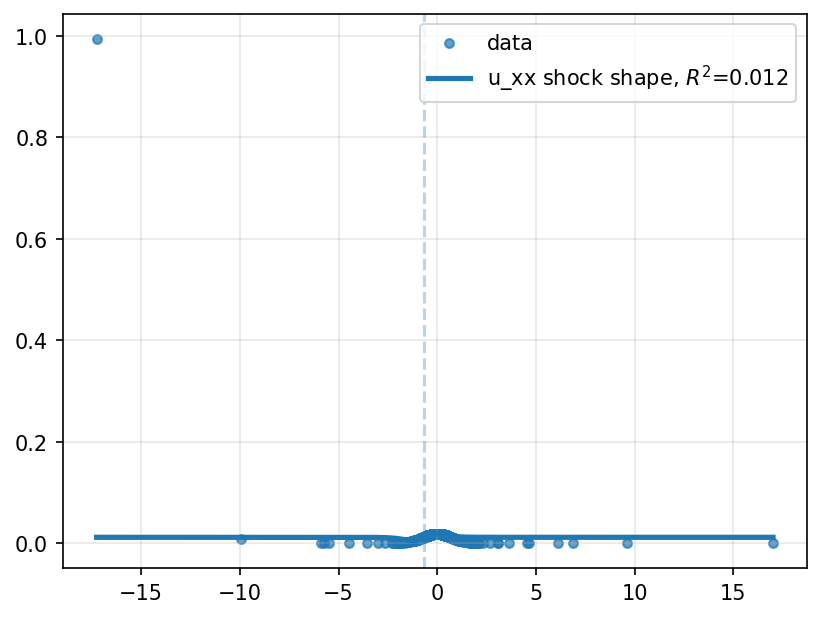

In [19]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def uxx_shock_shape(x, c, K, x0, ell):
    z = (x - x0) / ell
    sech2 = (1/np.cosh(z))**2
    return c + K * sech2 * np.tanh(z)   # odd shape

# ---- initial guesses ----
# x0 near where y crosses its midpoint or zero-crossing
# If you don't have a clean zero crossing, use argmin/argmax midpoint:
x0_0 = x[np.argmin(np.abs(y - np.median(y)))]
ell0 = np.std(x) / 8 if np.std(x) > 0 else 1.0
c0 = np.median(y)

# K sign from correlation with (x-x0): odd functions correlate with x-x0
K0 = np.sign(np.corrcoef((x - x0_0), (y - c0))[0,1] + 1e-12) * (np.ptp(y) + 1e-6)

p0 = [c0, K0, x0_0, ell0]

# bounds to keep ell positive and x0 in range
bounds = (
    [-np.inf, -np.inf, x.min(), 1e-6],
    [ np.inf,  np.inf, x.max(), np.inf]
)

params, _ = curve_fit(uxx_shock_shape, x, y, p0=p0, bounds=bounds, maxfev=400000)
c, K, x0, ell = params

y_hat = uxx_shock_shape(x, *params)
ss_tot = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_hat)**2)
r2 = 1 - ss_res/ss_tot

print("uxx shock params [c,K,x0,ell]:", params)
print("R^2:", r2)

# ---- plot smoothly ----
x_grid = np.linspace(x.min(), x.max(), 2000)
plt.figure(dpi=150)
plt.scatter(x, y, s=18, alpha=0.7, label="data")
plt.plot(x_grid, uxx_shock_shape(x_grid, *params), linewidth=2.5,
         label=f"u_xx shock shape, $R^2$={r2:.3f}")
plt.axvline(x0, alpha=0.3, linestyle="--")
plt.grid(alpha=0.3); plt.legend(); plt.show()


In [20]:
z = (x - x0) / ell
sech2 = (1/np.cosh(z))**2

# the "shape part" of y (remove fitted offset a)
y_shape = y - a

# corr with sech2
corr1 = np.corrcoef(sech2 - sech2.mean(), y_shape - y_shape.mean())[0,1]

# corr with -sech2 (in case your fitted A makes the model a - A*sech2)
corr2 = np.corrcoef(-sech2 + sech2.mean(), y_shape - y_shape.mean())[0,1]

print("corr(sech², y-a):", corr1)
print("corr(-sech², y-a):", corr2)
print("corr(y, y_hat):", np.corrcoef(y, y_hat)[0,1])
print("max abs error:", np.max(np.abs(y - y_hat)))


ValueError: operands could not be broadcast together with shapes (1770,) (20,) 

In [ ]:
import numpy as np

# fx must be the SAME thing you fed the model (same ddx scheme, same grid)
fx = ddx(0.5*u_pred**2)            # shape (B,Nx) or (Nx,)
fx = np.asarray(fx).ravel()
y  = np.arange(fx.shape[0])# np.asarray(y).ravel()

# fit y ≈ alpha*fx + beta
alpha, beta = np.polyfit(fx, y, 1)
y_aff = alpha*fx + beta

ss_tot = np.sum((y - y.mean())**2)
ss_res = np.sum((y - y_aff)**2)
r2_aff = 1 - ss_res/ss_tot

print("alpha, beta:", alpha, beta)
print("R^2 (affine fx -> y):", r2_aff)

alpha, beta: -0.6265304244917471 157.50000000061092
R^2 (affine fx -> y): 2.8459173186945463e-05


In [ ]:
import numpy as np

fx = ddx(0.5 * u_pred**2)          # should be (B, Nx)
fx = np.asarray(fx).ravel()

y = np.asarray(y).ravel()          # <-- THIS must be your edge activation

assert fx.shape == y.shape, (fx.shape, y.shape)

alpha, beta = np.polyfit(fx, y, 1)
y_aff = alpha * fx + beta

ss_tot = np.sum((y - y.mean())**2)
ss_res = np.sum((y - y_aff)**2)
r2_aff = 1 - ss_res / ss_tot

print("alpha, beta:", alpha, beta)
print("R^2 (affine fx -> y):", r2_aff)


alpha, beta: -0.6265304244917471 157.50000000061092
R^2 (affine fx -> y): 2.8459173186945463e-05


sech² params: [1.5251074  3.61694644 3.94313176 3.93106375]
R^2: 0.9984727356544209


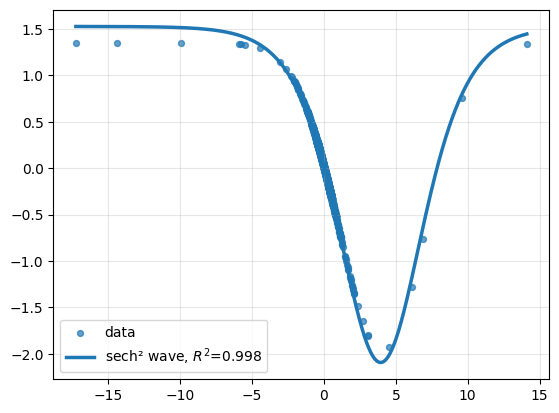

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def sech2_wave(x, a, A, x0, ell):
    z = (x - x0) / ell
    return a - A * (1 / np.cosh(z))**2

# initial guesses from data
a0 = np.percentile(y, 50)                 # plateau height
A0 = a0 - np.min(y)                       # depth
x0_0 = x[np.argmin(y)]                    # center of dip
ell0 = np.std(x) / 5                      # width

p0 = [a0, A0, x0_0, ell0]

params, _ = curve_fit(sech2_wave, x, y, p0=p0, maxfev=200000)
a, A, x0, ell = params

y_hat = sech2_wave(x, *params)

ss_res = np.sum((y - y_hat)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res / ss_tot

print("sech² params:", params)
print("R^2:", r2)
x_grid = np.linspace(x.min(), x.max(), 2000)

plt.scatter(x, y, s=18, alpha=0.7, label="data")
plt.plot(x_grid, sech2_wave(x_grid, *params),
         linewidth=2.5, label=f"sech² wave, $R^2$={r2:.3f}")
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [ ]:
# after fitting sech2_wave and getting params = [a, A, x0, ell]
z = (x - x0) / ell
sech2 = (1/np.cosh(z))**2

# IMPORTANT: remove the offset 'a' and the sign of A
y_centered = y - np.mean(y)
sech2_centered = sech2 - np.mean(sech2)

print("corr(sech²(best-fit), y):",
      np.corrcoef(sech2_centered, y_centered)[0,1])

corr(sech²(best-fit), y): -0.03692603780627801


In [ ]:
# after best-fit x0
xs = x - x0
order = np.argsort(xs)
xs = xs[order]
ys = y[order]

# interpolate y at symmetric points and compare
# (rough quick check)
left = ys[xs < 0]
right = ys[xs > 0][::-1]
n = min(len(left), len(right))
evenness = np.corrcoef(left[-n:], right[:n])[0,1]
print("even symmetry corr (near center):", evenness)


even symmetry corr (near center): -0.788230045238717


In [ ]:
z = (x - x0)/ell
odd_core = (1/np.cosh(z))**2 * np.tanh(z)

print("corr(sech², y):", np.corrcoef((1/np.cosh(z))**2, y)[0,1])
print("corr(sech²*tanh, y):", np.corrcoef(odd_core, y)[0,1])


corr(sech², y): -0.036926030124511254
corr(sech²*tanh, y): -0.9758223747107797


params [c, K, x0, ell]: [ 0.13432852 -3.90789289 -0.23426398  6.37668123]
R^2: 0.9522293086051052


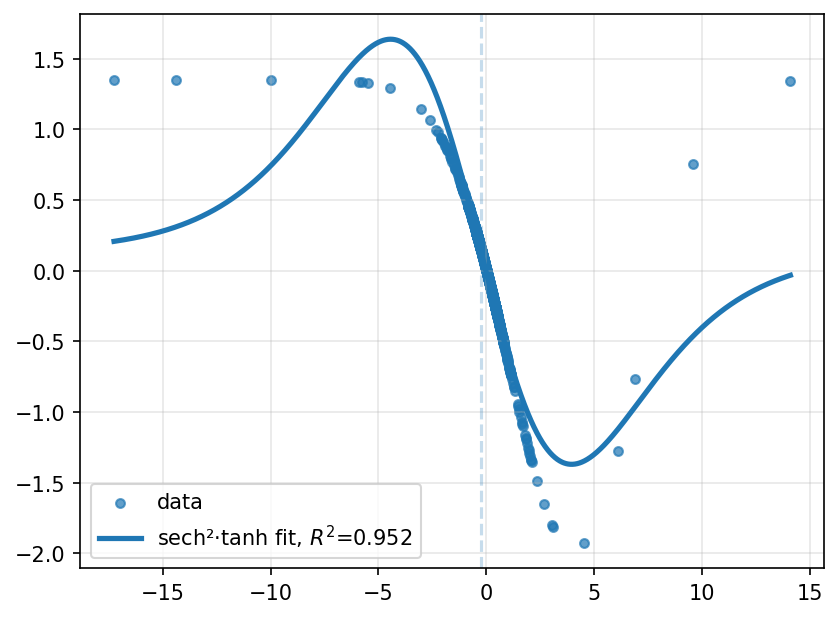

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def shock_flux_grad(x, c, K, x0, ell):
    z = (x - x0) / ell
    sech2 = (1/np.cosh(z))**2
    return c + K * sech2 * np.tanh(z)

# initial guesses
c0 = np.median(y)
x0_0 = x[np.argmin(np.abs(y - c0))]          # crude; can also use where y crosses c0
ell0 = np.std(x) / 8 if np.std(x) > 0 else 1.0
K0 = -np.sign(np.corrcoef(x - x0_0, y - c0)[0,1] + 1e-12) * (np.ptp(y) + 1e-6)

p0 = [c0, K0, x0_0, ell0]

bounds = (
    [-np.inf, -np.inf, x.min(), 1e-6],
    [ np.inf,  np.inf, x.max(), np.inf]
)

params, _ = curve_fit(shock_flux_grad, x, y, p0=p0, bounds=bounds, maxfev=400000)
y_hat = shock_flux_grad(x, *params)

ss_tot = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_hat)**2)
r2 = 1 - ss_res/ss_tot

print("params [c, K, x0, ell]:", params)
print("R^2:", r2)

# smooth plot
x_grid = np.linspace(x.min(), x.max(), 2000)
plt.figure(dpi=150)
plt.scatter(x, y, s=18, alpha=0.7, label="data")
plt.plot(x_grid, shock_flux_grad(x_grid, *params), linewidth=2.5,
         label=f"sech²·tanh fit, $R^2$={r2:.3f}")
plt.axvline(params[2], alpha=0.25, linestyle="--")
plt.grid(alpha=0.3); plt.legend(); plt.show()

R^2: 0.952982364571048


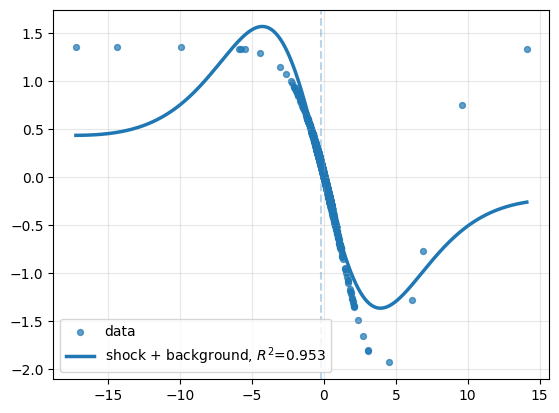

In [ ]:
def flux_grad_with_bg(x, a, b, K, x0, ell):
    z = (x - x0) / ell
    sech2 = (1/np.cosh(z))**2
    return a + b*x + K * sech2 * np.tanh(z)

# initial guesses
a0 = np.median(y)
b0 = np.polyfit(x, y, 1)[0] * 0.2   # gentle background slope
x0_0 = x[np.argmin(np.abs(y - a0))]
ell0 = np.std(x) / 8
K0 = -np.sign(np.corrcoef(x - x0_0, y - a0)[0,1]) * np.ptp(y)

p0 = [a0, b0, K0, x0_0, ell0]

bounds = (
    [-np.inf, -np.inf, -np.inf, x.min(), 1e-6],
    [ np.inf,  np.inf,  np.inf, x.max(), np.inf]
)

params, _ = curve_fit(
    flux_grad_with_bg,
    x, y,
    p0=p0,
    bounds=bounds,
    maxfev=500000
)

y_hat = flux_grad_with_bg(x, *params)

r2 = 1 - np.sum((y-y_hat)**2)/np.sum((y-np.mean(y))**2)
print("R^2:", r2)
xg = np.linspace(x.min(), x.max(), 2000)
plt.scatter(x, y, s=18, alpha=0.7, label="data")
plt.plot(xg, flux_grad_with_bg(xg, *params),
         linewidth=2.5, label=f"shock + background, $R^2$={r2:.3f}")
plt.axvline(params[3], ls="--", alpha=0.3)
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [ ]:
z = (x - x0)/ell
sech2 = (1/np.cosh(z))**2
print(np.corrcoef(sech2, y)[0,1])

-0.036926030124511254


In [ ]:
from scipy.optimize import curve_fit

def sin_model(x, A, w, phi, c):
    return A * np.sin(w * x + phi) + c

p0 = [1.0, 1.0, 0.0, 0.0]
params, _ = curve_fit(sin_model, x, y, p0=p0, maxfev=10000)
y_hat_sin_fit = sin_model(x, *params)

ss_res_sin_fit = np.sum((y - y_hat_sin_fit)**2)
r2_sin_fit = 1 - ss_res_sin_fit / ss_tot

print("Fitted sine params:", params)
print("Fitted sine R^2:", r2_sin_fit)

Fitted sine params: [-0.76315347  0.8662487   0.0132993   0.00500606]
Fitted sine R^2: 0.8065137958847777


In [ ]:
model = kan_pde
model.save_act=True
model(dataset['test_input'])
model.unfix_symbolic_all()
model.auto_symbolic(weight_simple=0.9, r2_threshold=0.2)
model.symbolic_formula()

saving model version 0.30
saving model version 0.31
For (0,0,0) the best fit was 0, but r^2 = 0.0 and this is lower than 0.2. This edge was omitted, keep training or try a different threshold.
For (0,1,0) the best fit was 0, but r^2 = 0.0 and this is lower than 0.2. This edge was omitted, keep training or try a different threshold.
saving model version 0.32


([1.36393742449582 - 0.0367766283452511*exp(-(4.0 - 3.46799993515015*x_1)**2) - 3.32648634910583*exp(-(0.952959895133972 - 0.235439985990524*x_2)**2)],
 [x_1, x_2])

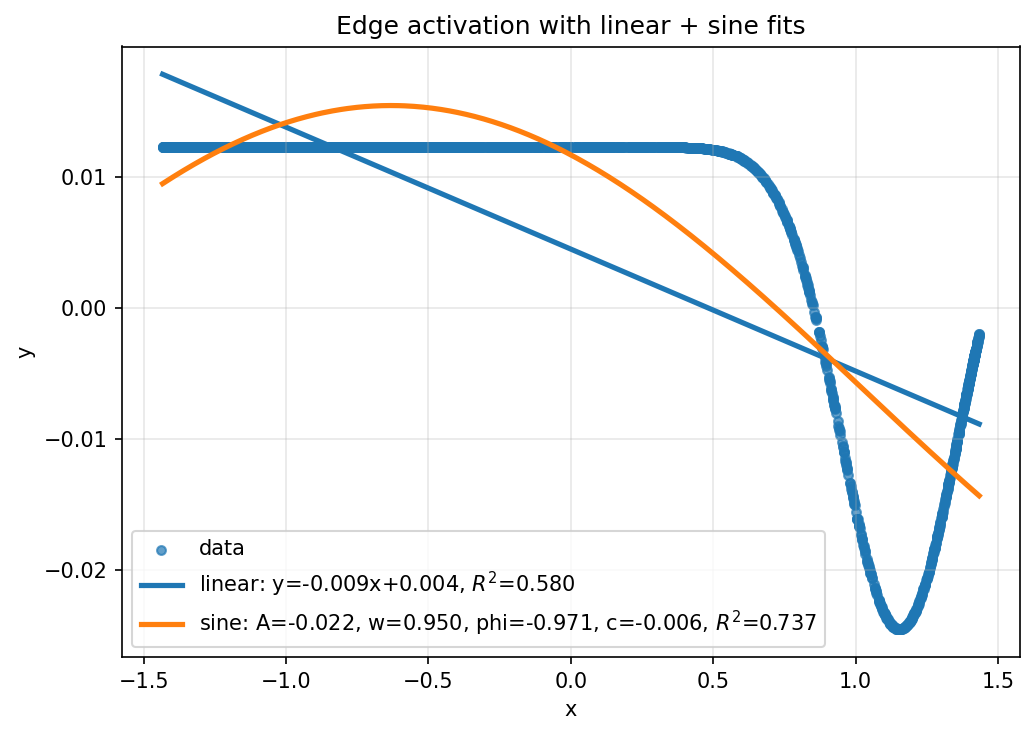

slope m = -0.009299
intercept b = 0.004480
R^2 (linear) = 0.580177
Fitted sine params: [-0.02152825  0.95018939 -0.97056905 -0.00610129]
R^2 (sine) = 0.736644


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- get x,y as you already do ---
kan_pde.save_act = True
kan_pde(dataset['train_input'])
x, y = get_edge_activation(kan_pde, 0, 0, 0, dataset['train_input'])

x = np.asarray(x).ravel()
y = np.asarray(y).ravel()

# ----- linear regression y = m x + b -----
m, b = np.polyfit(x, y, 1)
y_hat_lin = m * x + b

# standard R^2 (same ss_tot used for both)
ss_tot = np.sum((y - np.mean(y))**2)
ss_res_lin = np.sum((y - y_hat_lin)**2)
r2_lin = 1 - ss_res_lin / ss_tot

# ----- sine fit -----
def sin_model(x, A, w, phi, c):
    return A * np.sin(w * x + phi) + c

p0 = [1.0, 1.0, 0.0, 0.0]
params, _ = curve_fit(sin_model, x, y, p0=p0, maxfev=10000)
y_hat_sin = sin_model(x, *params)

ss_res_sin = np.sum((y - y_hat_sin)**2)
r2_sin = 1 - ss_res_sin / ss_tot

# ----- plot both fits on one figure -----
order = np.argsort(x)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(x, y, s=18, alpha=0.7, label="data")

plt.plot(
    x[order], y_hat_lin[order],
    linewidth=2.5,
    label=f"linear: y={m:.3f}x+{b:.3f}, $R^2$={r2_lin:.3f}"
)

plt.plot(
    x[order], y_hat_sin[order],
    linewidth=2.5,
    label=(f"sine: A={params[0]:.3f}, w={params[1]:.3f}, "
           f"phi={params[2]:.3f}, c={params[3]:.3f}, $R^2$={r2_sin:.3f}")
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Edge activation with linear + sine fits")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"slope m = {m:.6f}")
print(f"intercept b = {b:.6f}")
print(f"R^2 (linear) = {r2_lin:.6f}")
print("Fitted sine params:", params)
print(f"R^2 (sine) = {r2_sin:.6f}")

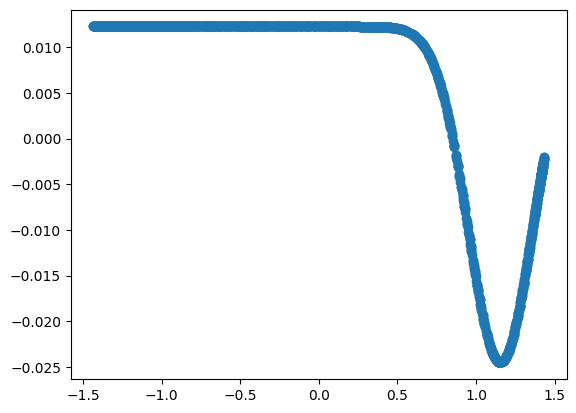

In [ ]:
plt.plot(x, y)
plt.scatter(x, y)

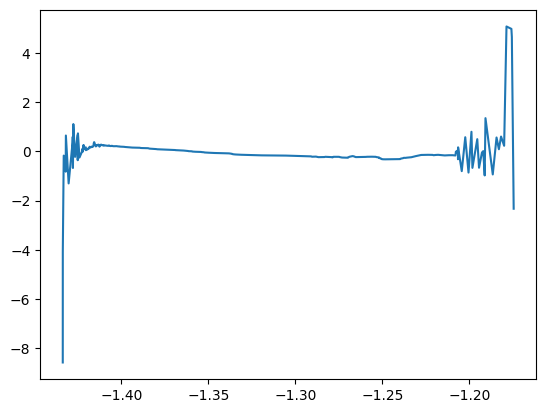

In [ ]:
fx = ddx(0.5 * u_pred**2)          # shape (B, Nx) or (1, Nx)

fx0 = np.asarray(fx[0]).ravel()    # (Nx,)
x0  = np.asarray(x[:fx0.shape[0]]).ravel()  # only if x is the grid for sample 0

plt.plot(x0, -fx0)
plt.show()


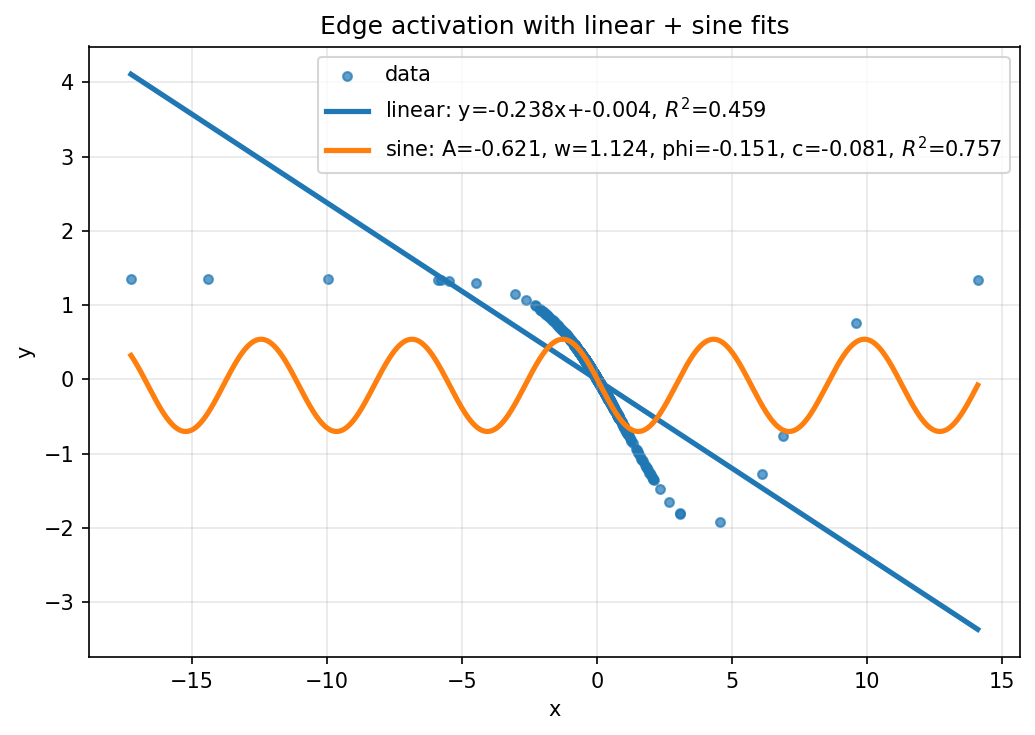

In [ ]:
order = np.argsort(x)

# smooth x-grid for plotting curves nicely
x_grid = np.linspace(x.min(), x.max(), 2000)

plt.figure(figsize=(7, 5), dpi=150)
plt.scatter(x, y, s=18, alpha=0.7, label="data")

# linear line (smooth)
plt.plot(
    x_grid, m * x_grid + b,
    linewidth=2.5,
    label=f"linear: y={m:.3f}x+{b:.3f}, $R^2$={r2_lin:.3f}"
)

# sine curve (smooth)
plt.plot(
    x_grid, sin_model(x_grid, *params),
    linewidth=2.5,
    label=(f"sine: A={params[0]:.3f}, w={params[1]:.3f}, "
           f"phi={params[2]:.3f}, c={params[3]:.3f}, $R^2$={r2_sin:.3f}")
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Edge activation with linear + sine fits")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from scipy.optimize import curve_fit
import numpy as np

def sin_plus_line(x, m, b, A, w, phi):
    return m*x + b + A*np.sin(w*x + phi)

# decent initial guess:
m0, b0 = np.polyfit(x, y, 1)
A0 = 0.5 * (np.percentile(y, 95) - np.percentile(y, 5))   # rough amplitude
w0 = 1.0
phi0 = 0.0
p0 = [m0, b0, A0, w0, phi0]

params, _ = curve_fit(sin_plus_line, x, y, p0=p0, maxfev=200000)
m_fit, b_fit, A_fit, w_fit, phi_fit = params

y_hat = sin_plus_line(x, *params)

ss_tot = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_hat)**2)
r2 = 1 - ss_res/ss_tot

print("sin+line params:", params)
print("R^2:", r2)


sin+line params: [-0.11562536 -0.08683678 -0.48983833  1.18473979 -0.20522483]
R^2: 0.8355536495083733


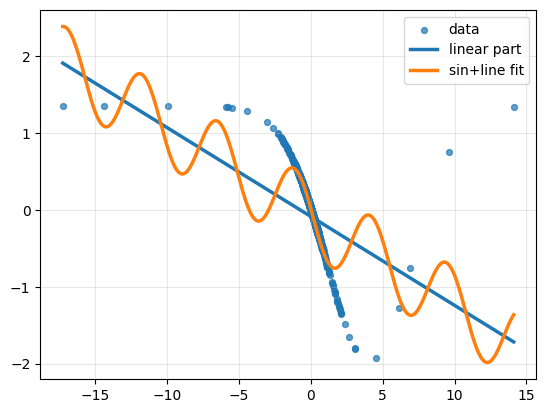

In [ ]:
x_grid = np.linspace(x.min(), x.max(), 2000)
plt.scatter(x, y, s=18, alpha=0.7, label="data")
plt.plot(x_grid, m_fit*x_grid + b_fit, linewidth=2.5, label="linear part")
plt.plot(x_grid, sin_plus_line(x_grid, *params), linewidth=2.5, label="sin+line fit")
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [ ]:
# Sine really doesn't fit.